## Modelo base — Referencia para comparar modelos de machine learning

### By:
Miguel Angel Toro Ramos

### Date:
2026-08-21

### Description:

Construcción de un modelo base (baseline) que sirva de referencia para comparar los modelos de
machine learning que se entrenen más adelante. Reutiliza el pipeline de preparación definido en el
notebook de ingeniería de atributos, replica la misma partición de entrenamiento y prueba, y evalúa
una heurística propia frente a modelos `Dummy` de scikit-learn.

## 📚 Import  libraries

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    get_scorer,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.utils.validation import check_is_fitted

## 💾 Load data

In [2]:
# resolve the project root by walking up until pyproject.toml is found,
# so the notebook works regardless of the directory Jupyter was launched from
PROJECT_DIR = next(
    p
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "pyproject.toml").exists()
)
DATA_DIR = PROJECT_DIR / "data"

admisiones_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admisiones_type_fixed.parquet", engine="pyarrow"
)

In [3]:
# print library version for reproducibility

print("Pandas version: ", pd.__version__)
print("sklearn version: ", sk.__version__)

Pandas version:  3.0.5
sklearn version:  1.9.0


## 👷 Data preparation

Se replican los mismos pasos de limpieza del notebook de ingeniería de atributos. Repetirlos aquí
—en lugar de partir de un archivo ya procesado— mantiene el notebook autocontenido y garantiza que
el modelo base se evalúe exactamente sobre los mismos datos que usarán los modelos posteriores.

### Missing values

Conteo de valores faltantes por columna antes de cualquier transformación.

In [4]:
admision_base = admisiones_df.copy()

In [5]:
admision_base.isna().sum()

GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0
dtype: int64

### Duplicate data

In [6]:
duplicate_rows = admision_base.duplicated().sum()
print("Number of duplicate rows: ", duplicate_rows)

Number of duplicate rows:  152


In [7]:
admision_base = admision_base.drop_duplicates()

In [8]:
admision_base.info()

<class 'pandas.DataFrame'>
Index: 471 entries, 0 to 581
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          460 non-null    Int64  
 1   TOEFL Score        452 non-null    Int64  
 2   University Rating  465 non-null    Int64  
 3   SOP                455 non-null    float64
 4   LOR                463 non-null    float64
 5   CGPA               469 non-null    float64
 6   Research           442 non-null    boolean
 7   Chance of Admit    471 non-null    float64
dtypes: Int64(3), boolean(1), float64(4)
memory usage: 31.7 KB


### Duplicados ocultos tras valores faltantes

`drop_duplicates()` compara valor a valor y `NaN` nunca es igual a `NaN`, de modo que dos registros
idénticos en los que uno perdió un dato no se detectan como duplicados. Se aplica el mismo criterio
de compatibilidad en el solapamiento observado que en la etapa de ingeniería de atributos: dos filas
son el mismo registro cuando coinciden en todas las columnas donde ambas tienen dato.

In [9]:
def marcar_duplicados_compatibles(frame):
    """Flag rows that repeat an earlier record.

    Two rows are treated as the same record when they agree on every column where
    both hold an observed value. Rows differing only in the position of a missing
    value are therefore detected, unlike `DataFrame.duplicated()`, for which NaN is
    never equal to NaN. The first occurrence of each group is kept.
    """
    values = frame.astype({column: "float64" for column in frame.columns}).to_numpy()
    observed = ~np.isnan(values)
    is_duplicate = np.zeros(len(values), dtype=bool)

    for i in range(len(values)):
        if is_duplicate[i]:
            continue
        both = observed[i] & observed[i + 1 :]
        same = np.where(both, values[i] == values[i + 1 :], True).all(axis=1) & both.any(axis=1)
        is_duplicate[np.nonzero(same)[0] + i + 1] = True

    return pd.Series(is_duplicate, index=frame.index)

In [10]:
duplicados_ocultos = marcar_duplicados_compatibles(admision_base)
print("Duplicados ocultos tras un valor faltante:", int(duplicados_ocultos.sum()))

admision_base = admision_base[~duplicados_ocultos]
print("Filas restantes:", len(admision_base))
print("Valores faltantes tras la deduplicación:", int(admision_base.isna().sum().sum()))

Duplicados ocultos tras un valor faltante: 71
Filas restantes: 400
Valores faltantes tras la deduplicación: 0


## 👨‍🏭 Feature Engineering

Se reconstruye el `ColumnTransformer` definido en el notebook anterior, sin cambios:

- **Numéricas continuas y ordinales**: imputación por mediana y estandarización.
- **Binaria**: `Research` se codifica con `OrdinalEncoder` a valores 0/1 y se imputa por moda.

Es indispensable que el modelo base vea exactamente la misma representación de los datos que verán
los modelos de machine learning. Si la preparación difiere, la comparación posterior deja de ser
válida: no se sabría si la diferencia de desempeño viene del modelo o del preprocesamiento.

In [11]:
cols_numeric = ["GRE Score", "TOEFL Score", "University Rating", "SOP", "LOR ", "CGPA"]
cols_binary = ["Research"]

Dos ajustes respecto del notebook de ingeniería de atributos, ambos necesarios para poder validar
el modelo con re-ajustes sucesivos del pipeline:

- `OrdinalEncoder` recibe `handle_unknown="use_encoded_value"` con `unknown_value=np.nan`. Sin esa
  opción, al re-ajustar el codificador sobre un subconjunto donde `Research` no presenta faltantes,
  el `NaN` de la partición de validación se trata como categoría desconocida y la transformación
  falla con `ValueError`. Con la opción activada el faltante llega como `NaN` al imputador, que lo
  resuelve por moda.
- `set_output(transform="pandas")` hace que el `ColumnTransformer` devuelva un `DataFrame` con los
  nombres de columna, lo que permite que `ModeloBase` seleccione su predictor por nombre cuando se
  encadena dentro de un `Pipeline`.

In [12]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

binary_pipe = Pipeline(
    steps=[
        # unknown_value keeps unseen categories (including NaN) as NaN so the
        # imputer resolves them, instead of raising when the encoder is refitted
        # on a subset that never saw them
        (
            "encoder",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan),
        ),
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipe, cols_numeric),
        ("binary", binary_pipe, cols_binary),
    ]
)

# return DataFrames so downstream steps can select columns by name
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [13]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

## ✂️ Train / Test split

La partición replica exactamente la del notebook de ingeniería de atributos: `test_size=0.2`,
`random_state=42` y estratificación por quintiles del objetivo construidos con `pd.qcut`.

Mantener el mismo `random_state` y el mismo criterio de estratificación no es un detalle: si el
modelo base se midiera sobre una partición distinta a la de los modelos posteriores, las métricas no
serían comparables y el baseline perdería su razón de ser.

In [14]:
X_features = admision_base.drop(columns=["Chance of Admit "])
Y_target = admision_base["Chance of Admit "]

# 80% train, 20% test
y_bins = pd.qcut(Y_target, q=5, labels=False, duplicates="drop")
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, random_state=42, stratify=y_bins
)

In [15]:
x_train.shape, y_train.shape

((320, 7), (320,))

In [16]:
x_test.shape, y_test.shape

((80, 7), (80,))

### Preprocessing pipeline

El `preprocessor` se ajusta únicamente con `x_train` y luego se aplica a ambas particiones sin
recalcularse, para evitar fuga de información desde el conjunto de prueba.

In [17]:
# fit the preprocessor on the training set only, to avoid data leakage
preprocessor.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [18]:
# set_output already returns DataFrames with the transformed feature names
x_train_transformed = preprocessor.transform(x_train)
x_test_transformed = preprocessor.transform(x_test)
x_train_transformed.info()

<class 'pandas.DataFrame'>
Index: 320 entries, 190 to 314
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   numeric__GRE Score          320 non-null    float64
 1   numeric__TOEFL Score        320 non-null    float64
 2   numeric__University Rating  320 non-null    float64
 3   numeric__SOP                320 non-null    float64
 4   numeric__LOR                320 non-null    float64
 5   numeric__CGPA               320 non-null    float64
 6   binary__Research            320 non-null    float64
dtypes: float64(7)
memory usage: 20.0 KB


### Verificación: duplicados y fuga tras la transformación

La imputación puede crear duplicados donde no los había: dos filas que solo diferían en un valor
ausente quedan idénticas al rellenarse ese hueco con el mismo estadístico. Y si esas filas cayeron
en particiones distintas, el conjunto de prueba contendría observaciones ya vistas durante el
ajuste.

Esta comprobación se mantiene como verificación permanente: con la deduplicación por compatibilidad
aplicada, ambos conteos deben ser cero.

In [19]:
print("Duplicados en train transformado:", int(x_train_transformed.duplicated().sum()))
print("Duplicados en test transformado: ", int(x_test_transformed.duplicated().sum()))

Duplicados en train transformado: 0
Duplicados en test transformado:  0


In [20]:
# test rows whose transformed features already exist in the training set
train_keys = set(map(tuple, x_train_transformed.round(10).to_numpy()))
overlap = np.array([tuple(row) in train_keys for row in x_test_transformed.round(10).to_numpy()])

print(
    f"Filas de test con gemela exacta en train: {overlap.sum()} de {len(overlap)}"
    f" ({overlap.mean():.1%})"
)

Filas de test con gemela exacta en train: 0 de 80 (0.0%)


## 🎯 Selección de la variable más importante

El modelo base se construye sobre un único predictor, de modo que la elección determina por completo
su desempeño. El criterio es la fuerza de la asociación con el objetivo, medida con dos
coeficientes complementarios:

- **Pearson** cuantifica la asociación lineal.
- **Spearman** cuantifica la asociación monótona, sin suponer linealidad.

Cuando ambos coinciden, la relación es lineal y no hay curvatura que un modelo simple deje sin
capturar.

Los coeficientes se calculan **solo sobre el conjunto de entrenamiento**. Seleccionar la variable
mirando el conjunto completo sería una forma de fuga: la decisión estaría informada por datos que el
modelo no debería haber visto.

In [21]:
correlaciones = []
for columna in [*cols_numeric, *cols_binary]:
    observado = x_train[columna].notna()
    valores = x_train.loc[observado, columna].astype(float).to_numpy()
    objetivo = y_train.loc[x_train.index[observado]].to_numpy()
    correlaciones.append(
        {
            "variable": columna,
            "pearson": np.corrcoef(valores, objetivo)[0, 1],
            "spearman": pd.Series(valores).corr(pd.Series(objetivo), method="spearman"),
            "n": len(valores),
        }
    )

correlaciones_df = (
    pd.DataFrame(correlaciones)
    .set_index("variable")
    .sort_values("pearson", key=abs, ascending=False)
)
correlaciones_df.round(4)

,pearson,spearman,n
variable,,,
CGPA,0.8825,0.8871,320
GRE Score,0.8159,0.8289,320
TOEFL Score,0.8007,0.8042,320
University Rating,0.7090,0.7214,320
SOP,0.6981,0.7074,320
LOR,0.6723,0.6679,320
Research,0.5596,0.5953,320


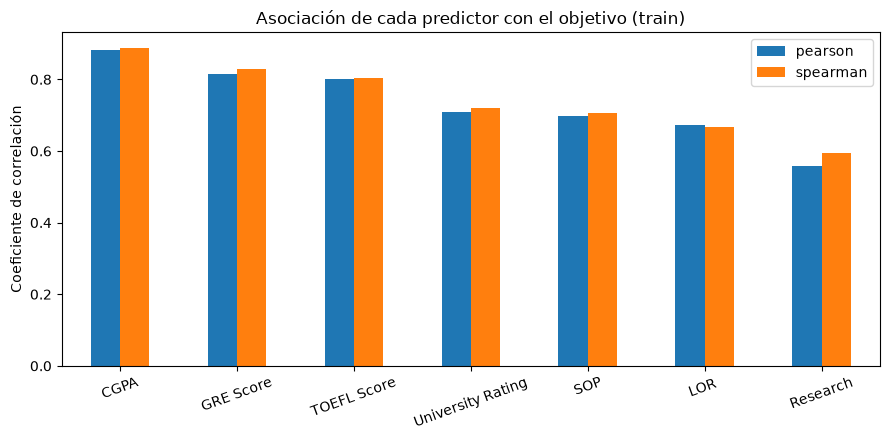

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
correlaciones_df[["pearson", "spearman"]].plot(kind="bar", ax=ax, rot=20)
ax.set_title("Asociación de cada predictor con el objetivo (train)")
ax.set_ylabel("Coeficiente de correlación")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

**`CGPA` es la variable seleccionada.** Presenta la correlación más alta con el objetivo (Pearson
0.8825, Spearman 0.8843) y la diferencia con el segundo predictor, `GRE Score` (0.8167), es de casi
siete puntos. La coincidencia entre ambos coeficientes en todas las variables confirma además que
las relaciones son lineales, sin efectos de umbral.

La justificación va más allá del número. `CGPA` es el promedio académico acumulado: resume el
desempeño sostenido del postulante a lo largo de toda su carrera, mientras que GRE y TOEFL miden una
única prueba y `SOP`, `LOR ` y `University Rating` son valoraciones subjetivas o contextuales. Que la
variable más predictiva sea también la de mayor respaldo sustantivo refuerza la elección: no es un
artefacto de la muestra.

`Research`, en el extremo opuesto, es binaria y no admite una partición en cinco intervalos por
cuantiles, por lo que resulta inadecuada para esta heurística con independencia de su correlación.

Más adelante se verifica empíricamente que esta elección es también la de mejor desempeño.

## 🧱 Modelo base

`ModeloBase` implementa una heurística transparente: divide el predictor más correlacionado con el
objetivo —`CGPA`, según el análisis univariable— en intervalos por cuantiles, y predice para cada
observación el promedio del objetivo observado en su intervalo durante el entrenamiento.

La clase sigue la interfaz de scikit-learn:

- Hereda de `RegressorMixin` y `BaseEstimator`, lo que le da `get_params`, `set_params` y `score`
  (R²) sin escribirlos.
- `__init__` solo guarda hiperparámetros, sin validarlos ni derivar nada, como exige la convención.
- `fit` aprende los cortes y los promedios **solo del conjunto de entrenamiento**, guarda los
  atributos aprendidos con sufijo `_` y devuelve `self`.
- `predict` verifica que el modelo esté ajustado con `check_is_fitted` antes de predecir.

Respetar esa interfaz permite usarla dentro de un `Pipeline`, de `cross_val_score` o de una búsqueda
de hiperparámetros exactamente igual que a cualquier estimador de la librería.

In [23]:
class ModeloBase(RegressorMixin, BaseEstimator):
    """Heuristic baseline regressor.

    Splits a single feature into quantile bins and predicts, for each sample, the
    mean target value observed in that bin during training. Samples that fall in a
    bin unseen at fit time fall back to the global training mean.

    Parameters
    ----------
    feature : str, default="numeric__CGPA"
        Name of the column used to build the bins.
    n_bins : int, default=5
        Number of quantile bins.

    Attributes
    ----------
    bin_edges_ : ndarray
        Bin boundaries learned from the training set.
    bin_means_ : dict
        Mean target value per bin index.
    default_ : float
        Global training mean, used as fallback.
    """

    def __init__(self, feature="numeric__CGPA", n_bins=5):
        self.feature = feature
        self.n_bins = n_bins

    def fit(self, X, y):
        if self.feature not in X.columns:
            raise ValueError(f"Column {self.feature!r} is not present in X")

        values = pd.Series(np.asarray(X[self.feature], dtype=float))
        target = pd.Series(np.asarray(y, dtype=float))

        # quantile edges learned from the training set only
        quantiles = np.linspace(0, 1, self.n_bins + 1)
        self.bin_edges_ = np.unique(values.quantile(quantiles).to_numpy())
        self.bin_edges_[0], self.bin_edges_[-1] = -np.inf, np.inf

        bins = np.digitize(values, self.bin_edges_[1:-1])
        self.bin_means_ = target.groupby(bins).mean().to_dict()
        self.default_ = float(target.mean())
        self.is_fitted_ = True
        return self

    def predict(self, X):
        check_is_fitted(self)
        values = np.asarray(X[self.feature], dtype=float)
        bins = np.digitize(values, self.bin_edges_[1:-1])
        return np.array([self.bin_means_.get(b, self.default_) for b in bins])

### Entrenamiento del modelo base

El modelo se ajusta sobre el conjunto de entrenamiento transformado.

In [24]:
modelo_base = ModeloBase()
modelo_base.fit(x_train_transformed, y_train)

,feature,'numeric__CGPA'
,n_bins,5
Name,Type,Value
bin_edges_,"ndarray[float64](6,)","[ -inf,-0.89,-0.24, 0.27, 0.91, inf]"
bin_means_,dict,"{0: 0.5406349206349207, 1: 0.6712307692307693, 2: 0.7104761904761905, 3: 0.78328125, ...}"
default_,float,0.7243
is_fitted_,bool,True


In [25]:
# bins learned on the training set and their mean target value
pd.DataFrame(
    {
        "intervalo": range(len(modelo_base.bin_means_)),
        "limite_inferior": modelo_base.bin_edges_[:-1],
        "limite_superior": modelo_base.bin_edges_[1:],
        "prediccion": list(modelo_base.bin_means_.values()),
    }
)

,intervalo,limite_inferior,limite_superior,prediccion
0,0,-inf,-0.885220,0.540635
1,1,-0.885220,-0.236919,0.671231
2,2,-0.236919,0.273659,0.710476
3,3,0.273659,0.911883,0.783281
4,4,0.911883,inf,0.910769


## 🔮 Predict

Se predice sobre el conjunto de prueba, que el modelo no vio durante el ajuste.

In [26]:
y_pred_base = modelo_base.predict(x_test_transformed)
y_pred_base[:10]

array([0.54063492, 0.71047619, 0.78328125, 0.78328125, 0.91076923,
       0.71047619, 0.67123077, 0.67123077, 0.91076923, 0.91076923])

In [27]:
pd.DataFrame({"real": y_test.to_numpy(), "prediccion": y_pred_base}, index=y_test.index).head(10)

,real,prediccion
169,0.65,0.540635
75,0.72,0.710476
392,0.84,0.783281
99,0.79,0.783281
25,0.94,0.910769
391,0.71,0.710476
226,0.63,0.671231
321,0.73,0.671231
72,0.93,0.910769
382,0.82,0.910769


## 📏 Evaluación

`Chance of Admit ` es una variable continua, de modo que el problema es de **regresión** y las
métricas de clasificación (accuracy, precisión, F1) no aplican. Se evalúa con:

- **MAE** — error absoluto medio, en las unidades del objetivo. Como `Chance of Admit ` va de 0 a 1,
  un MAE de 0.07 se lee directamente como "el modelo se equivoca en 7 puntos de probabilidad en
  promedio". Es la métrica más interpretable para comunicar el resultado.
- **RMSE** — penaliza más los errores grandes. Comparado con el MAE indica si existen pocos casos
  con desvíos severos.
- **R²** — proporción de la varianza del objetivo explicada por el modelo.

Para dimensionar la heurística se la compara contra dos modelos `Dummy` de scikit-learn, que
representan el piso absoluto: predecir siempre la media o siempre la mediana del entrenamiento.

In [28]:
def evaluar(nombre, modelo):
    modelo.fit(x_train_transformed, y_train)
    y_pred = modelo.predict(x_test_transformed)
    return {
        "modelo": nombre,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
    }


resultados = pd.DataFrame(
    [
        evaluar("ModeloBase (CGPA por quintiles)", ModeloBase()),
        evaluar("DummyRegressor (media)", DummyRegressor(strategy="mean")),
        evaluar("DummyRegressor (mediana)", DummyRegressor(strategy="median")),
    ]
).set_index("modelo")

resultados.round(4)

,MAE,RMSE,R2
modelo,,,
ModeloBase (CGPA por quintiles),0.0690,0.0906,0.6057
DummyRegressor (media),0.1174,0.1442,-0.0000
DummyRegressor (mediana),0.1175,0.1443,-0.0015


In [29]:
# RegressorMixin provides score(), which returns R^2 for regressors
modelo_base.score(x_test_transformed, y_test)

0.6056569011711331

## 📈 Validación cruzada y curvas

Las métricas de la sección anterior provienen de una única partición de 95 filas, por lo que su
varianza es considerable. Para caracterizar el comportamiento del modelo base se lo evalúa con
validación cruzada sobre el conjunto de entrenamiento.

El modelo se encadena con el `preprocessor` en un único `Pipeline`. Esto es indispensable: al
validar, cada partición debe re-ajustar también la imputación y el escalado con sus propios datos.
Si el preprocesamiento se ajustara una sola vez fuera del bucle, cada pliegue de validación
recibiría estadísticos calculados con datos que no debería haber visto.

In [30]:
# preprocessor + model as a single estimator, so cross-validation refits both
model_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", ModeloBase())])
model_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.

El objetivo es continuo, de modo que las métricas son de regresión. scikit-learn expresa los errores
en negativo (`neg_mean_absolute_error`) porque su convención es que un valor mayor siempre indica
mejor desempeño; al presentarlos se les invierte el signo para leerlos como errores.

In [31]:
# Evaluation metrics: regression, not classification
scoring_metrics = ["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"]
metric_labels = {
    "neg_mean_absolute_error": "MAE",
    "neg_root_mean_squared_error": "RMSE",
    "r2": "R2",
}

# KFold for the cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {}
train_results = {}

model_pipe.fit(x_train, y_train)

for metric in scoring_metrics:
    cv_results[metric_labels[metric]] = cross_val_score(
        model_pipe, x_train, y_train, cv=kfold, scoring=metric
    )
    # get_scorer applies the requested metric; model_pipe.score() would always
    # return R2 regardless of the metric being evaluated
    train_results[metric_labels[metric]] = get_scorer(metric)(model_pipe, x_train, y_train)

cv_results_df = pd.DataFrame(cv_results)

# error metrics come back negated by scikit-learn convention
for column in ["MAE", "RMSE"]:
    cv_results_df[column] = -cv_results_df[column]
    train_results[column] = -train_results[column]

for name in cv_results_df.columns:
    print(
        f"{name:5s} - CV mean: {cv_results_df[name].mean():.4f}, "
        f"CV std: {cv_results_df[name].std():.4f}, "
        f"Train: {train_results[name]:.4f}"
    )

MAE   - CV mean: 0.0558, CV std: 0.0071, Train: 0.0552
RMSE  - CV mean: 0.0721, CV std: 0.0092, Train: 0.0718
R2    - CV mean: 0.7235, CV std: 0.0514, Train: 0.7446


### Dispersión entre particiones

El diagrama de caja muestra cuánto varía cada métrica entre los diez pliegues. Los errores y el R²
se grafican por separado porque están en escalas distintas: MAE y RMSE en unidades del objetivo, R²
como proporción adimensional.

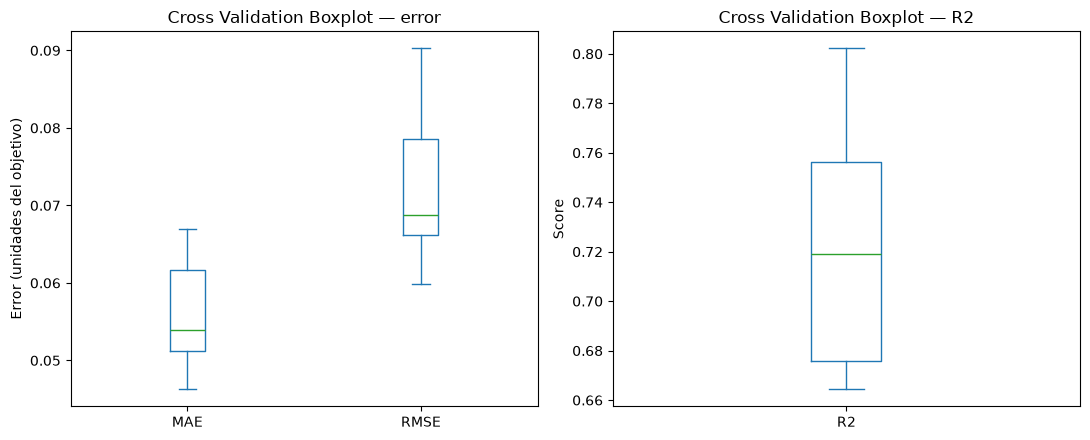

In [32]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))

cv_results_df[["MAE", "RMSE"]].plot.box(ax=axes[0])
axes[0].set_title("Cross Validation Boxplot — error")
axes[0].set_ylabel("Error (unidades del objetivo)")

cv_results_df[["R2"]].plot.box(ax=axes[1])
axes[1].set_title("Cross Validation Boxplot — R2")
axes[1].set_ylabel("Score")

fig.tight_layout()
plt.show()

### Entrenamiento frente a validación

Comparar el desempeño sobre el conjunto de entrenamiento con la media de validación cruzada indica
si el modelo memoriza. Las barras de error representan la desviación estándar entre pliegues.

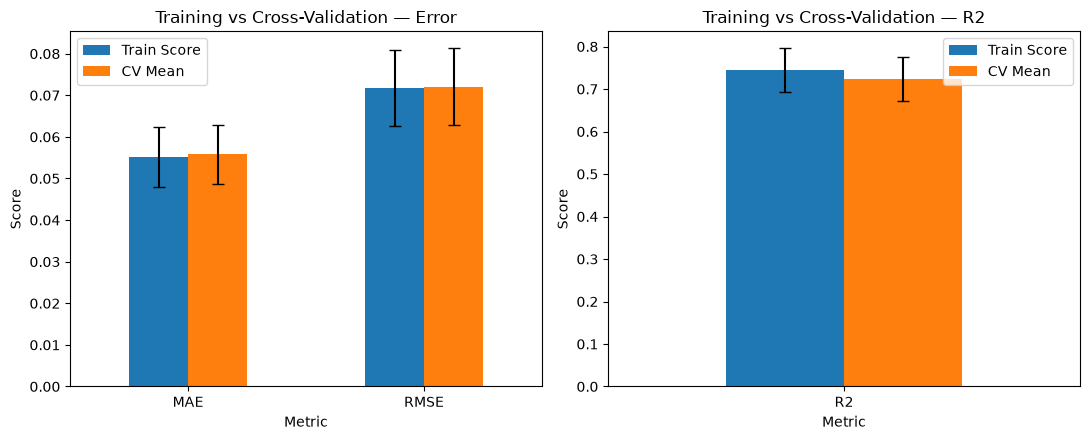

,Train Score,CV Mean,CV Std
Metric,,,
MAE,0.0552,0.0558,0.0071
RMSE,0.0718,0.0721,0.0092
R2,0.7446,0.7235,0.0514


In [33]:
metrics_df = pd.DataFrame(
    {
        "Metric": cv_results_df.columns,
        "Train Score": [train_results[m] for m in cv_results_df.columns],
        "CV Mean": [cv_results_df[m].mean() for m in cv_results_df.columns],
        "CV Std": [cv_results_df[m].std() for m in cv_results_df.columns],
    }
).set_index("Metric")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))

for ax, group, title in (
    (axes[0], ["MAE", "RMSE"], "Error"),
    (axes[1], ["R2"], "R2"),
):
    subset = metrics_df.loc[group]
    subset.plot(
        kind="bar",
        y=["Train Score", "CV Mean"],
        yerr=subset["CV Std"],
        ax=ax,
        capsize=4,
        rot=0,
    )
    ax.set_title(f"Training vs Cross-Validation — {title}")
    ax.set_ylabel("Score")

fig.tight_layout()
plt.show()

metrics_df.round(4)

### Verificación empírica de la variable seleccionada

La elección de `CGPA` se apoyó en su correlación con el objetivo. Conviene comprobar que esa
elección también es la mejor en términos de desempeño: se evalúa el mismo `ModeloBase` construido
sobre cada predictor disponible, con idéntico protocolo de validación cruzada.

In [34]:
seleccion = []
for columna in [*cols_numeric, *cols_binary]:
    nombre = ("numeric__" if columna in cols_numeric else "binary__") + columna
    puntajes = cross_val_score(
        Pipeline(steps=[("preprocessor", preprocessor), ("model", ModeloBase(feature=nombre))]),
        x_train,
        y_train,
        cv=kfold,
        scoring="r2",
    )
    seleccion.append(
        {"variable": columna, "R2 CV media": puntajes.mean(), "R2 CV desv": puntajes.std(ddof=1)}
    )

seleccion_df = (
    pd.DataFrame(seleccion).set_index("variable").sort_values("R2 CV media", ascending=False)
)
seleccion_df.round(4)

,R2 CV media,R2 CV desv
variable,,
CGPA,0.7235,0.0514
GRE Score,0.5961,0.0967
TOEFL Score,0.5706,0.1750
University Rating,0.4384,0.1907
SOP,0.4220,0.1402
LOR,0.3852,0.1375
Research,-0.0621,0.0804


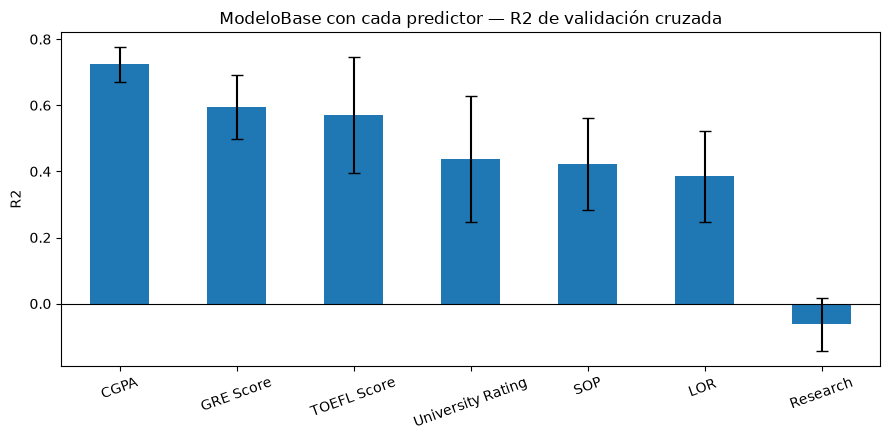

In [35]:
fig, ax = plt.subplots(figsize=(9, 4.5))
seleccion_df["R2 CV media"].plot(
    kind="bar", yerr=seleccion_df["R2 CV desv"], ax=ax, capsize=4, rot=20
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("ModeloBase con cada predictor — R2 de validación cruzada")
ax.set_ylabel("R2")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

### Curva de aprendizaje

La curva de aprendizaje muestra cómo evolucionan el desempeño de entrenamiento y el de validación a
medida que crece el número de observaciones disponibles. Permite distinguir dos situaciones: si
ambas curvas convergen en un valor bajo, el modelo está limitado por su propia capacidad; si quedan
separadas, está memorizando el conjunto de entrenamiento.

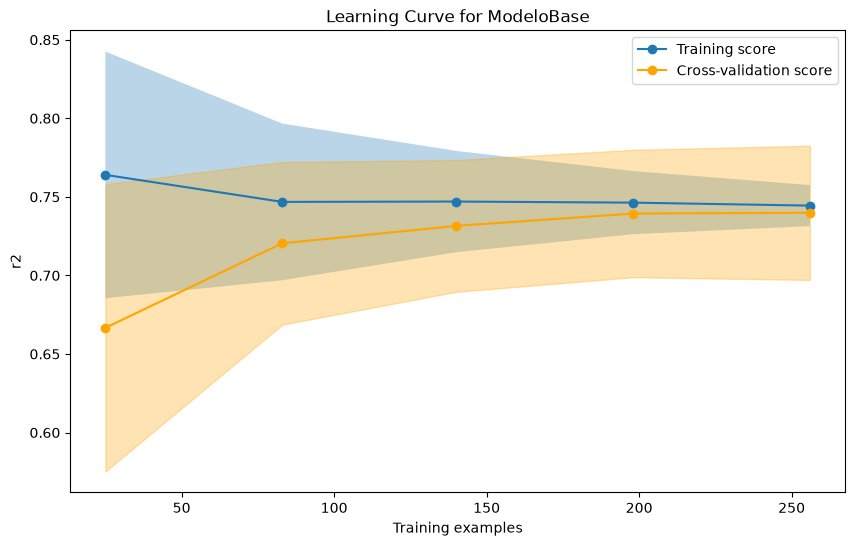

Training Sizes: [ 25  83 140 198 256]
Training Scores Mean: [0.764  0.7468 0.747  0.7463 0.7444]
Test Scores Mean:     [0.6667 0.7205 0.7315 0.7394 0.7399]
Test Scores Std:      [0.0915 0.0518 0.0419 0.0406 0.0427]


In [36]:
common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
}

scoring_metric = "r2"

train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    model_pipe, **common_params, scoring=scoring_metric
)

train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
test_mean, test_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)
fit_times_mean, fit_times_std = np.mean(fit_times, axis=1), np.std(fit_times, axis=1)
score_times_mean, score_times_std = (
    np.mean(score_times, axis=1),
    np.std(score_times, axis=1),
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, "o-", label="Training score")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange")
ax.set_title(f"Learning Curve for {ModeloBase.__name__}")
ax.set_xlabel("Training examples")
ax.set_ylabel(scoring_metric)
ax.legend(loc="best")
plt.show()

print("Training Sizes:", train_sizes)
print("Training Scores Mean:", np.round(train_mean, 4))
print("Test Scores Mean:    ", np.round(test_mean, 4))
print("Test Scores Std:     ", np.round(test_std, 4))

### Escalabilidad

Tiempos de ajuste y de predicción en función del tamaño del conjunto de entrenamiento.

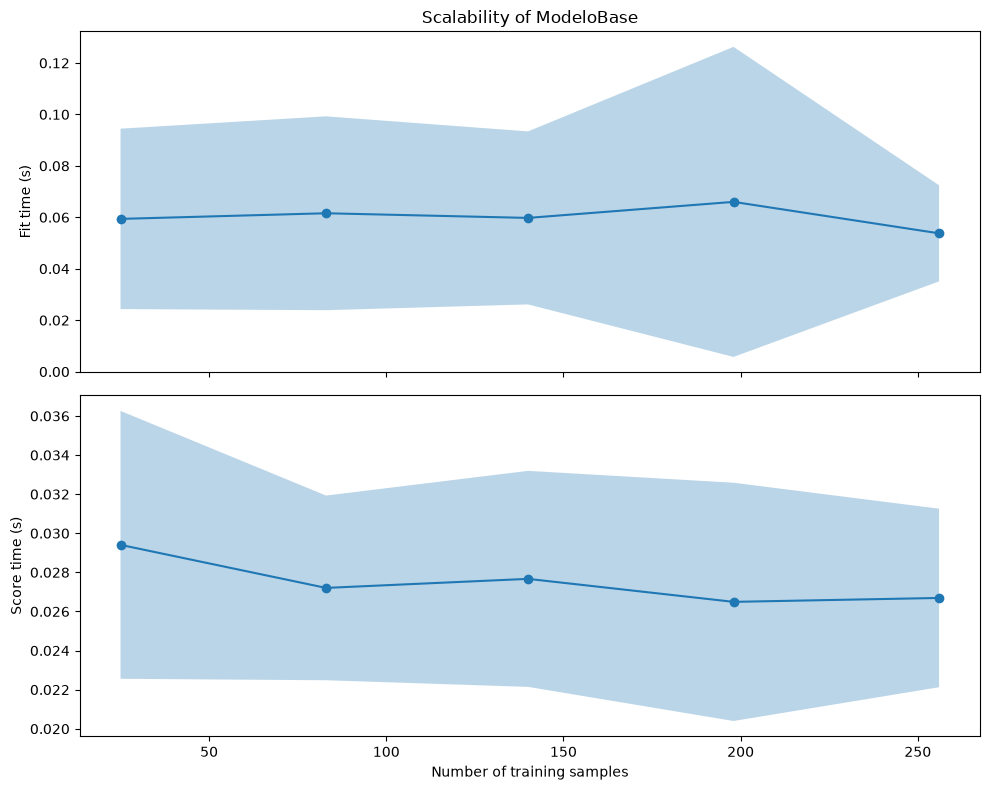

Fit Times Mean:   [0.05939 0.06158 0.05977 0.066   0.05377]
Score Times Mean: [0.02941 0.02721 0.02767 0.02649 0.02669]


In [37]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

ax[0].plot(train_sizes, fit_times_mean, "o-")
ax[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title(f"Scalability of {ModeloBase.__name__}")

ax[1].plot(train_sizes, score_times_mean, "o-")
ax[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)
ax[1].set_ylabel("Score time (s)")
ax[1].set_xlabel("Number of training samples")

fig.tight_layout()
plt.show()

print("Fit Times Mean:  ", np.round(fit_times_mean, 5))
print("Score Times Mean:", np.round(score_times_mean, 5))

### Comparación contra los modelos de referencia

Las tres alternativas evaluadas sobre el conjunto de prueba. Para un problema de regresión no existe
un `classification_report`; su equivalente es contrastar predicciones contra valores reales y
examinar la distribución del error.

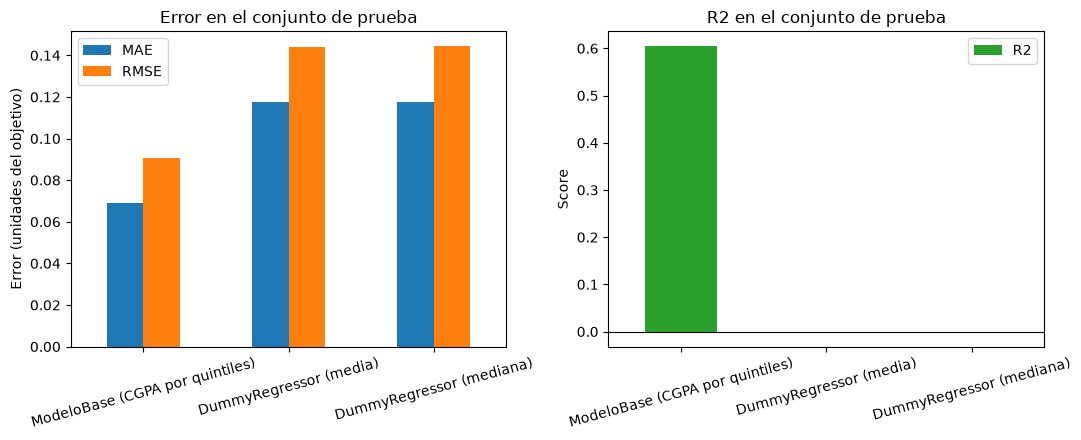

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))

resultados[["MAE", "RMSE"]].plot(kind="bar", ax=axes[0], rot=15, capsize=4)
axes[0].set_title("Error en el conjunto de prueba")
axes[0].set_ylabel("Error (unidades del objetivo)")
axes[0].set_xlabel("")

resultados[["R2"]].plot(kind="bar", ax=axes[1], rot=15, color="tab:green")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("R2 en el conjunto de prueba")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("")

fig.tight_layout()
plt.show()

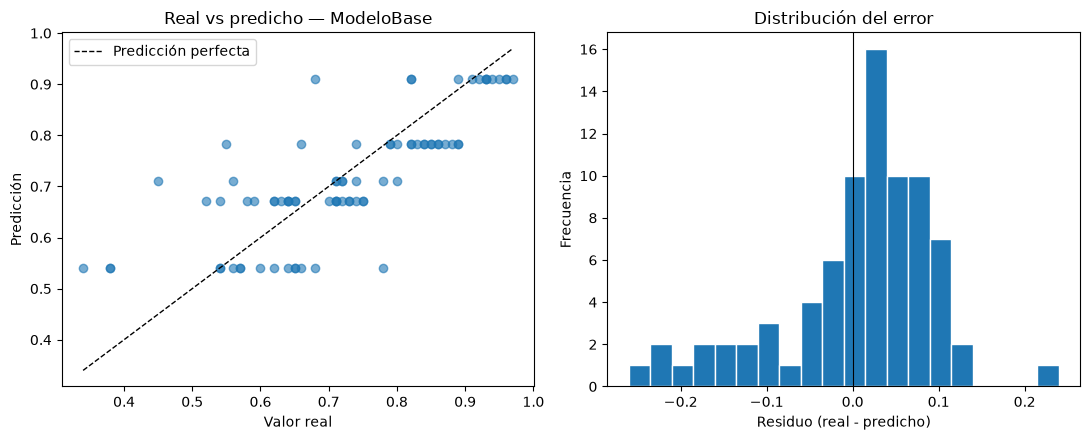

Residuo medio: +0.0064
Residuo absoluto maximo: 0.2605


In [39]:
residuals = y_test.to_numpy() - y_pred_base

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4.5))

axes[0].scatter(y_test, y_pred_base, alpha=0.6)
lims = [min(y_test.min(), y_pred_base.min()), max(y_test.max(), y_pred_base.max())]
axes[0].plot(lims, lims, "--", color="black", linewidth=1, label="Predicción perfecta")
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Predicción")
axes[0].set_title("Real vs predicho — ModeloBase")
axes[0].legend(loc="best")

axes[1].hist(residuals, bins=20, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Residuo (real - predicho)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución del error")

fig.tight_layout()
plt.show()

print(f"Residuo medio: {residuals.mean():+.4f}")
print(f"Residuo absoluto maximo: {np.abs(residuals).max():.4f}")

## 📊 Analysis of Results and Conclusions

**Modelo base.** `ModeloBase` implementa una heurística sobre `CGPA`, el predictor con mayor
correlación con el objetivo: divide la variable en cinco intervalos por cuantiles y predice, para
cada observación, el promedio del objetivo observado en su intervalo durante el entrenamiento. Todo
el modelo son cinco cortes y cinco promedios aprendidos únicamente del conjunto de entrenamiento.

**Preparación de datos.** El conjunto de partida tiene 623 filas. La deduplicación exacta descarta
152 y la deduplicación por compatibilidad en el solapamiento observado descarta 71 más, dejando 400
registros distintos y sin valores faltantes. La partición 80/20 con `random_state=42`, estratificada
por quintiles del objetivo, produce 320 filas de entrenamiento y 80 de prueba.

**Interfaz de scikit-learn.** La clase hereda de `RegressorMixin` y `BaseEstimator`, mantiene los
hiperparámetros sin transformar en `__init__`, expone los atributos aprendidos con sufijo `_`,
devuelve `self` desde `fit` y valida el ajuste con `check_is_fitted` antes de predecir. Cumplir esa
convención es lo que permite encadenarla con el `preprocessor` en un `Pipeline` y pasarla a
`cross_val_score` y `learning_curve` sin adaptadores, además de aportar `get_params`, `set_params` y
`score` sin escribirlos.

**Selección de la variable.** `CGPA` se eligió por presentar la correlación más alta con el objetivo
sobre el conjunto de entrenamiento (Pearson 0.8825, Spearman 0.8871), casi siete puntos por encima
de `GRE Score`. La verificación empírica confirma la decisión: evaluando el mismo `ModeloBase` sobre
cada predictor con idéntico protocolo de validación cruzada, `CGPA` alcanza R² 0.7235 frente a
0.5961 de `GRE Score` y 0.5706 de `TOEFL Score`. `Research` obtiene -0.0621, peor que predecir la
media, porque una variable binaria no admite una partición en cinco intervalos por cuantiles.

**Métricas sobre el conjunto de prueba.** El objetivo es continuo, por lo que el problema es de
regresión y las métricas de clasificación no aplican:

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| ModeloBase (CGPA por quintiles) | 0.0690 | 0.0906 | +0.6057 |
| DummyRegressor (media) | 0.1174 | 0.1442 | -0.0000 |
| DummyRegressor (mediana) | 0.1175 | 0.1443 | -0.0015 |

El MAE se lee directamente en las unidades del objetivo: la heurística se equivoca en promedio 6.9
puntos de probabilidad de admisión, frente a los 11.7 de predecir siempre la media. El error se
reduce aproximadamente a la mitad.

**Sobre el R² de los modelos Dummy.** El valor cercano a cero del `DummyRegressor(strategy="mean")`
no indica un fallo: R² se define comparando contra la predicción de la media, de modo que un modelo
que predice exactamente la media obtiene cero por construcción, y sobre un conjunto de prueba
distinto al de ajuste puede resultar levemente negativo. Es precisamente la referencia que da
sentido a la métrica.

**Validación cruzada.** Diez particiones sobre el conjunto de entrenamiento, con el `preprocessor`
re-ajustado en cada una:

| Métrica | Train | CV media | CV desviación |
|---|---|---|---|
| MAE | 0.0552 | 0.0558 | 0.0071 |
| RMSE | 0.0718 | 0.0721 | 0.0092 |
| R² | 0.7446 | 0.7235 | 0.0514 |

La diferencia entre entrenamiento y validación es de 0.021 puntos de R² y de 0.0006 de MAE. Un
margen tan estrecho indica que el modelo **no memoriza**, lo cual es esperable: con cinco parámetros
no hay capacidad para hacerlo.

La diferencia entre el R² de validación cruzada (0.7235) y el del conjunto de prueba (0.6057) es
mayor que la desviación entre pliegues y merece atención. Con 80 observaciones de prueba, una única
partición basta para producir esa distancia; la estimación por validación cruzada, que promedia diez
particiones, es la referencia más fiable de las dos y es la que debe usarse para comparar modelos
posteriores.

**Curva de aprendizaje.** El desempeño de entrenamiento se mantiene estable alrededor de 0.744
mientras el de validación asciende de 0.667 con 25 observaciones a 0.740 con 256, reduciendo su
desviación de 0.092 a 0.043. Las dos curvas prácticamente se juntan al final, lo que sitúa al modelo
en un régimen de sesgo alto y varianza baja: el límite no está en la cantidad de datos sino en la
capacidad del propio modelo. Para un baseline eso es exactamente lo deseable —una referencia estable,
que no depende de cuántos datos reciba— y anticipa que un modelo con mayor capacidad sí podría
aprovechar la información que la heurística deja sin explotar.

**Escalabilidad.** Los tiempos de ajuste y de predicción se mantienen constantes al crecer el
conjunto de entrenamiento. El coste computacional es irrelevante y no constituye un criterio de
comparación frente a modelos posteriores.

**Distribución del error.** El gráfico de valor real frente a predicho muestra la naturaleza
escalonada de la heurística: solo existen cinco predicciones posibles, una por intervalo. El residuo
medio es +0.0064, prácticamente centrado, con un error absoluto máximo de 0.2605. Ese caso extremo
—cerca de 26 puntos de probabilidad— es la limitación estructural del enfoque: dentro de un mismo
intervalo de `CGPA` todas las observaciones reciben idéntica predicción, sin importar el resto de
sus atributos.

**Conclusión sobre el baseline.** Una sola variable y cinco promedios explican en torno al 72% de la
varianza del objetivo en validación cruzada. Ese es el listón que deben superar los modelos de
machine learning que se entrenen a continuación, y no es bajo: una mejora marginal sobre este valor
no justificaría la complejidad añadida.

**Correcciones aplicadas al pipeline.** Encadenar el preprocesamiento dentro del `Pipeline` reveló un
defecto que la evaluación sobre una partición única no exponía. `OrdinalEncoder`, sin
`handle_unknown`, falla con `ValueError` cuando se re-ajusta sobre un subconjunto en el que
`Research` no presenta faltantes y luego debe transformar una partición que sí los tiene. Se corrigió
con `handle_unknown="use_encoded_value"` y `unknown_value=np.nan`. Es un defecto que habría aparecido
igualmente al poner el pipeline en producción frente a datos nuevos.

**Deduplicación por compatibilidad y eliminación de la fuga.** Una versión anterior de este notebook
documentaba 11 filas duplicadas en entrenamiento y 2 en prueba tras la imputación, y 5 de las 95
observaciones de prueba (5.3%) con una gemela exacta en entrenamiento. La causa era que
`drop_duplicates()` no detecta registros que solo difieren en la posición de un valor ausente,
porque `NaN` nunca es igual a `NaN`; al imputar, esas filas colapsaban. Incorporada la deduplicación
por compatibilidad en el solapamiento observado, la verificación posterior a la transformación
reporta **0 duplicados en ambas particiones y 0% de solapamiento**. La comprobación se conserva como
control permanente.

El efecto sobre las métricas es revelador. El R² medio de validación cruzada apenas se movió, de
0.7157 a 0.7235, pero **su desviación entre pliegues cayó de 0.1054 a 0.0514**, menos de la mitad.
La fuga no estaba inflando tanto el valor central como distorsionando su estabilidad: mientras un
mismo registro podía repartirse entre pliegues, algunas particiones resultaban artificialmente
fáciles y otras no. Con la corrección, la estimación es comparable a la anterior pero mucho más
fiable, que es exactamente lo que se necesita de un baseline destinado a servir de referencia.

**Limitaciones.** La muestra útil es de 400 registros, un 36% menos que las 623 filas del archivo de
partida. Con 80 observaciones de prueba, cualquier métrica calculada sobre esa partición conserva
varianza considerable, y de ahí la distancia observada entre el R² de prueba y el de validación
cruzada. La heurística, además, ignora por completo cinco de los seis predictores disponibles: es
una decisión deliberada para mantener la referencia simple y auditable, no una afirmación de que el
resto no aporte información.

## 🧭 Recomendaciones para construir el modelo

A partir de lo observado con el modelo base:

**1. El listón a superar es R² ≈ 0.72 y MAE ≈ 0.056 en validación cruzada, no las cifras de prueba.**
La estimación por validación cruzada promedia diez particiones y es más fiable que la del conjunto
de prueba, que proviene de una sola y con 80 observaciones conserva varianza apreciable. Todo modelo
posterior debe compararse con el mismo protocolo: `KFold` de diez particiones, mismo `random_state`,
y el preprocesamiento encadenado dentro del `Pipeline`.

**2. Verificar la ausencia de fuga en cada iteración.** La deduplicación por compatibilidad ya está
incorporada y la comprobación posterior a la transformación reporta cero duplicados y cero
solapamiento. Conviene mantener esa verificación al introducir nuevos pasos de preparación: cualquier
transformación que rellene valores puede volver a colapsar filas distintas en idénticas.

**3. Empezar por modelos lineales.** Las relaciones entre predictores y objetivo son
aproximadamente lineales —Pearson y Spearman casi coinciden— y el objetivo está acotado en [0, 1].
Una regresión lineal regularizada (`Ridge`, `Lasso`, `ElasticNet`) es la continuación natural:
aprovecha esa linealidad, usa las seis variables en lugar de una, y sigue siendo interpretable.
Modelos de mayor capacidad deberían justificarse frente a ella, no frente al baseline.

**4. Usar las variables que la heurística descarta.** `ModeloBase` ignora cinco de los seis
predictores. `GRE Score` y `TOEFL Score` presentan correlaciones de 0.82 y 0.80 con el objetivo, y
por sí solas alcanzan R² de 0.60 y 0.57. La ganancia esperable de un modelo multivariable está ahí,
aunque conviene medir la colinealidad: las tres variables académicas están fuertemente asociadas
entre sí y su aporte conjunto será menor que la suma de sus aportes individuales.

**5. Reportar MAE junto con R².** El MAE se expresa en las unidades del objetivo y permite decidir si
el modelo sirve: un error medio de 6.9 puntos de probabilidad de admisión es interpretable por
cualquier persona, mientras que un R² de 0.72 no lo es. Para comunicar resultados a quien deba tomar
decisiones, el MAE es la métrica útil.

**6. No optimizar contra el conjunto de prueba.** Con 80 filas y una desviación de 0.051 en R² entre
particiones, las diferencias menores a 0.05 entre modelos no son distinguibles del ruido. Las
decisiones de selección deben tomarse con validación cruzada sobre entrenamiento, reservando el
conjunto de prueba para una única medición final. Al comparar modelos conviene además emplear una
prueba estadística sobre los resultados por pliegue, y no quedarse en la diferencia de medias.

**7. Vigilar el sobreajuste desde el principio.** El modelo base tiene una separación de 0.021 entre
entrenamiento y validación. Ese valor es la referencia: un modelo cuya brecha sea notablemente mayor
está memorizando, aunque su R² de entrenamiento parezca mejor.

**8. Acotar las predicciones al rango válido.** El objetivo es una probabilidad en [0, 1]. Un modelo
lineal sin restricciones puede predecir valores fuera de ese intervalo, lo que resulta imposible de
justificar ante un usuario. Conviene recortar la salida o modelar la variable transformada.

**9. Considerar el tamaño real de la muestra al elegir la complejidad.** Con 320 filas de
entrenamiento y seis predictores, modelos con muchos parámetros o hiperparámetros libres tenderán a
sobreajustar. La optimización de hiperparámetros debe hacerse siempre con validación cruzada anidada
o, como mínimo, sin tocar el conjunto de prueba.

## 💡 Proposals and Ideas

- Trasladar la deduplicación por compatibilidad a la etapa de datos intermedios, de modo que
  `admisiones_type_fixed.parquet` se publique ya sin duplicados y ningún notebook posterior deba
  repetirla.
- Documentar en la etapa de adquisición que el archivo de partida contiene 223 filas duplicadas
  sobre 400 registros reales, para evitar que futuras cargas reintroduzcan el problema.
- Normalizar los nombres de columna: `LOR ` y `Chance of Admit ` tienen espacios finales, lo que
  obliga a replicarlos literalmente en todo el código y es una fuente silenciosa de `KeyError`.
- Comparar la heurística actual contra variantes: otro predictor de corte, distinto número de
  intervalos, o una regla lineal simple sobre `CGPA`.
- Trasladar la construcción del `preprocessor` y la deduplicación a `src/pipelines/feature_pipeline/`
  para que los notebooks los importen en lugar de redefinirlos, y cubrirlos con pruebas en
  `tests/pipelines/feature_pipeline/`.
- Registrar las métricas del baseline en `data/08_reporting/` para compararlas de forma sistemática
  con los modelos posteriores.
- Evaluar si conviene ampliar el conjunto de prueba o sustituirlo por validación cruzada anidada,
  dado que 80 observaciones producen estimaciones con varianza apreciable.

## 📖 References

- [Ciencia de datos con Python — Baseline model, José R. Zapata](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/)
- [scikit-learn — Developing scikit-learn estimators](https://scikit-learn.org/stable/developers/develop.html)
- [scikit-learn — DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html)
- [scikit-learn — Metrics for regression](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)
- [scikit-learn — Common pitfalls: data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)